In [2]:

import anndata as ad
import celltypist
from celltypist import models
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [5]:
list_of_anndatas = ['bd-rhap-rep2.h5ad', 'bd-rhap-rep1.h5ad', '10x-rep2-kallisto-cellbender.h5ad','10x-rep1-kallisto-cellbender.h5ad', ]
fold = ['bd-rhap-rep2', 'bd-rhap-rep1', '10x-rep2-kallisto-cellbender', '10x-rep1-kallisto-cellbender']

list_of_stats = {}
n_cells = []
n_genes = []
names = []

for ad, fo in zip(list_of_anndatas, fold):
    adata = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/{fo}/{ad}')
    dataset_stats = adata.obs['celltype_semi_manual'].value_counts()
    strad = ad.replace('-wk.h5ad', "")
    strad = strad.replace('blood-', '')
    strad = strad.replace('-kallisto-cellbender', "")
    names.append(strad)
    list_of_stats[strad] = dataset_stats
    n_cells.append(adata.shape[0])
    n_genes.append(adata.shape[1])





In [6]:
data_dimensions = pd.DataFrame({'name':strad, "n_genes": n_genes, 'n_cells': n_cells})

<Axes: ylabel='Gene count'>

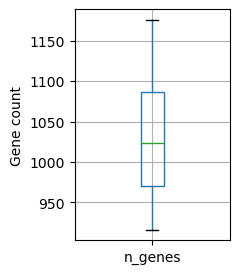

In [7]:
plt.figure(figsize=(2, 3)) 
plt.ylabel('Gene count')
plt.xlabel('')
data_dimensions.loc[:, ['n_genes']].boxplot()

<Axes: ylabel='Cell count'>

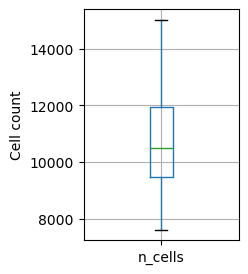

In [8]:
plt.figure(figsize=(2, 3)) 
plt.ylabel('Cell count')
data_dimensions.loc[:, ['n_cells']].boxplot()

In [9]:
stat_table = pd.DataFrame(list_of_stats).T

In [10]:
# 1. Calculate the sum of each row
row_sums = stat_table.sum(axis=1)

# 2. Divide each row by its corresponding sum
# We must specify axis=0 to align the row sums with the rows
normalized_table = stat_table.div(row_sums, axis=0)

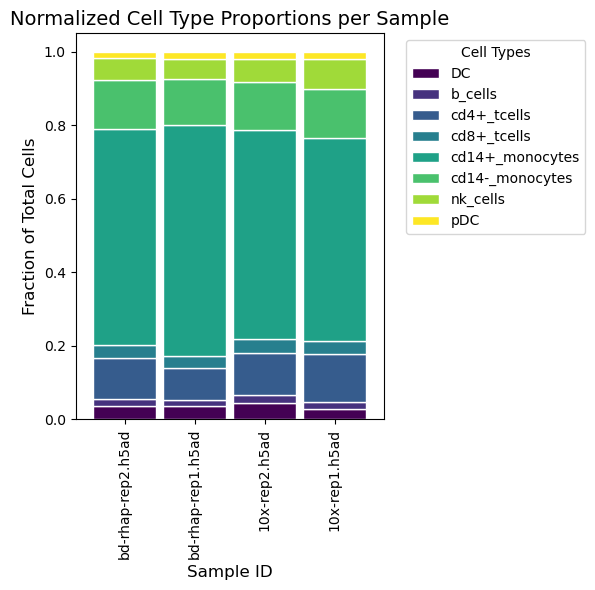

In [11]:


# 3. Create the stacked bar plot
ax = normalized_table.plot(kind='bar', 
                        stacked=True, 
                        colormap='viridis', 
                        edgecolor='white',
                        figsize=(6, 6),
                        width=0.9)

# Formatting the chart
plt.title('Normalized Cell Type Proportions per Sample', fontsize=14)
plt.xlabel('Sample ID', fontsize=12)
plt.ylabel('Fraction of Total Cells', fontsize=12)
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()

In [13]:
runtime_stats = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/time_tracker.tsv', index_col=0)

In [14]:
runtime_stats.columns = ['run', 'runtime']

In [15]:
runtime_stats['runtime'] = runtime_stats['runtime']/60

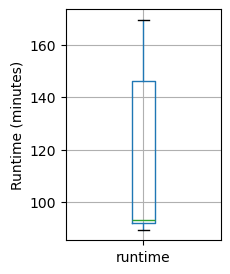

In [16]:
# Width of 4 inches, Height of 6 inches
plt.figure(figsize=(2, 3)) 
runtime_stats.boxplot()
# 3. Add your Y-axis label
plt.ylabel('Runtime (minutes)')
plt.show()

In [17]:
plt.show()